# Experiment 8 - Warna (RGB) + Tekstur (GLCM) dengan Preprocessing Bertahap

**Pipeline Preprocessing:**
1. **Baseline**: Resize + grayscale (acuan)
2. **Gray World White Balance** (koreksi warna iluminasi)
3. **Bilateral Filter** (smoothing tepi-preserving, mengurangi noise)
4. **CLAHE** (peningkatan kontras adaptif pada grayscale)

**Fitur yang diekstrak:**
- **Fitur Warna (dari RGB)**: Mean, Std, Skewness per channel R, G, B
- **Fitur Tekstur (GLCM dari grayscale)**: Contrast, Homogeneity, Dissimilarity, Energy, ASM, Entropy, Correlation (4 sudut)

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import (
    gray_world_white_balance,
    bilateral_filter,
    clahe,
    extract_color_features,
    visualize_pipeline_steps,
)
from tqdm import tqdm

EXPERIMENT_NAME = "experiment8"
import gc

# Nonaktifkan GPU CuPy untuk pemrosesan citra per-gambar sekuensial
import src.image_processing as ip
ip.USING_GPU = False
ip.xp = np


c:\Users\Mahesa\miniconda3\envs\imgproc\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


CuPy aktif - komputasi berjalan di GPU


## Data Loading

In [3]:
import gc
gc.collect()
DATASET_ROOT = get_dataset_root()
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256), color=True)
print(f"Dataset loaded: {len(images)} gambar, {len(set(labels))} kelas")


Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Dataset loaded: 8455 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 8455 gambar, 7 kelas


In [4]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# Tambah, hapus, atau ganti fungsi sesuai experiment
# ================================================================

PIPELINE = [
    lambda img: gray_world_white_balance(img),
    lambda img: bilateral_filter(img, d=9, sigma_color=75.0, sigma_space=75.0),
    lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
    lambda img: clahe(img, tile_size=8, clip_limit=2.0)
]

# ================================================================
# Jangan edit di bawah ini
# ================================================================

def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image


## Preprocessing

**Urutan operasi:**
1. Gambar asli (resize 256x256, BGR)
2. Setelah **Gray World White Balance** → warna konsisten
3. Setelah **Bilateral Filter** → edge-preserving smoothing
4. Setelah **CLAHE** (pada grayscale) → kontras lokal meningkat


In [5]:
# Ambil 1 sampel per kelas awan untuk visualisasi
class_names = sorted(list(set(labels)))
sample_indices = []
for cls in class_names:
    idx_val = np.where(labels == cls)[0][0]
    sample_indices.append(idx_val)

print(f"Kelas awan: {class_names}")
print(f"Jumlah kelas: {len(class_names)}")
print(f"Sampel indices: {sample_indices}")


Kelas awan: ['altocumulus', 'cirrus', 'clearsky', 'cumulonimbus', 'cumulus', 'mixed', 'stratocumulus']
Jumlah kelas: 7
Sampel indices: [np.int64(0), np.int64(1250), np.int64(2500), np.int64(3750), np.int64(5000), np.int64(6250), np.int64(7205)]


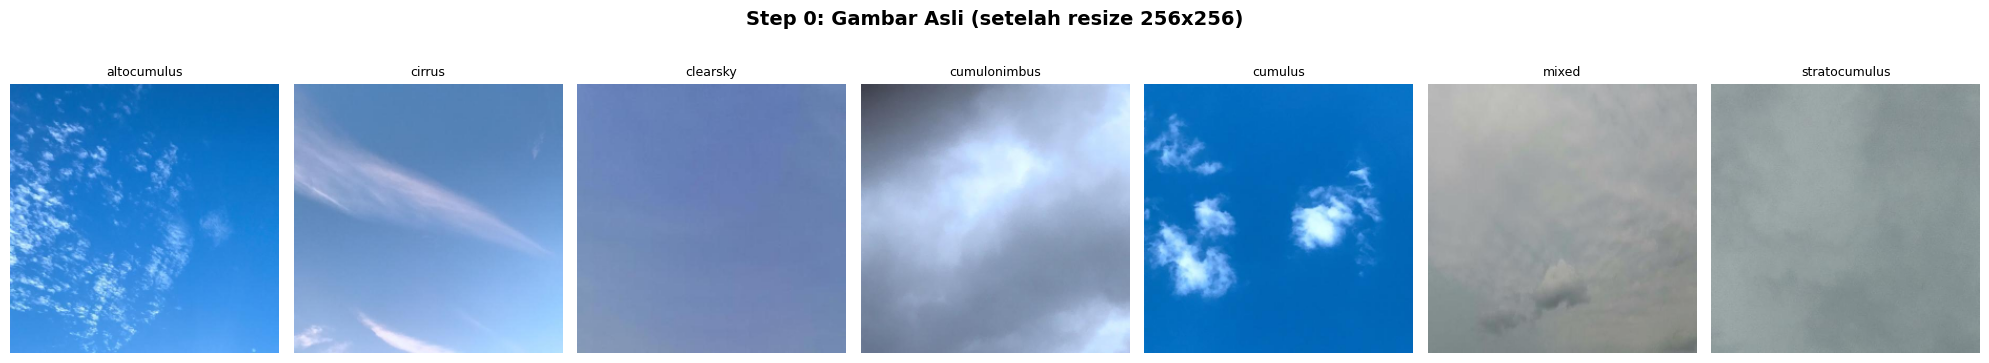

In [6]:
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4))
fig.suptitle('Step 0: Gambar Asli (setelah resize 256x256)', fontsize=14, fontweight='bold')

for i, (idx, cls) in enumerate(zip(sample_indices, class_names)):
    img_bgr = images[idx]  # BGR format dari OpenCV
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f'viz_{EXPERIMENT_NAME}_step0_original.png', dpi=100, bbox_inches='tight')
plt.show()

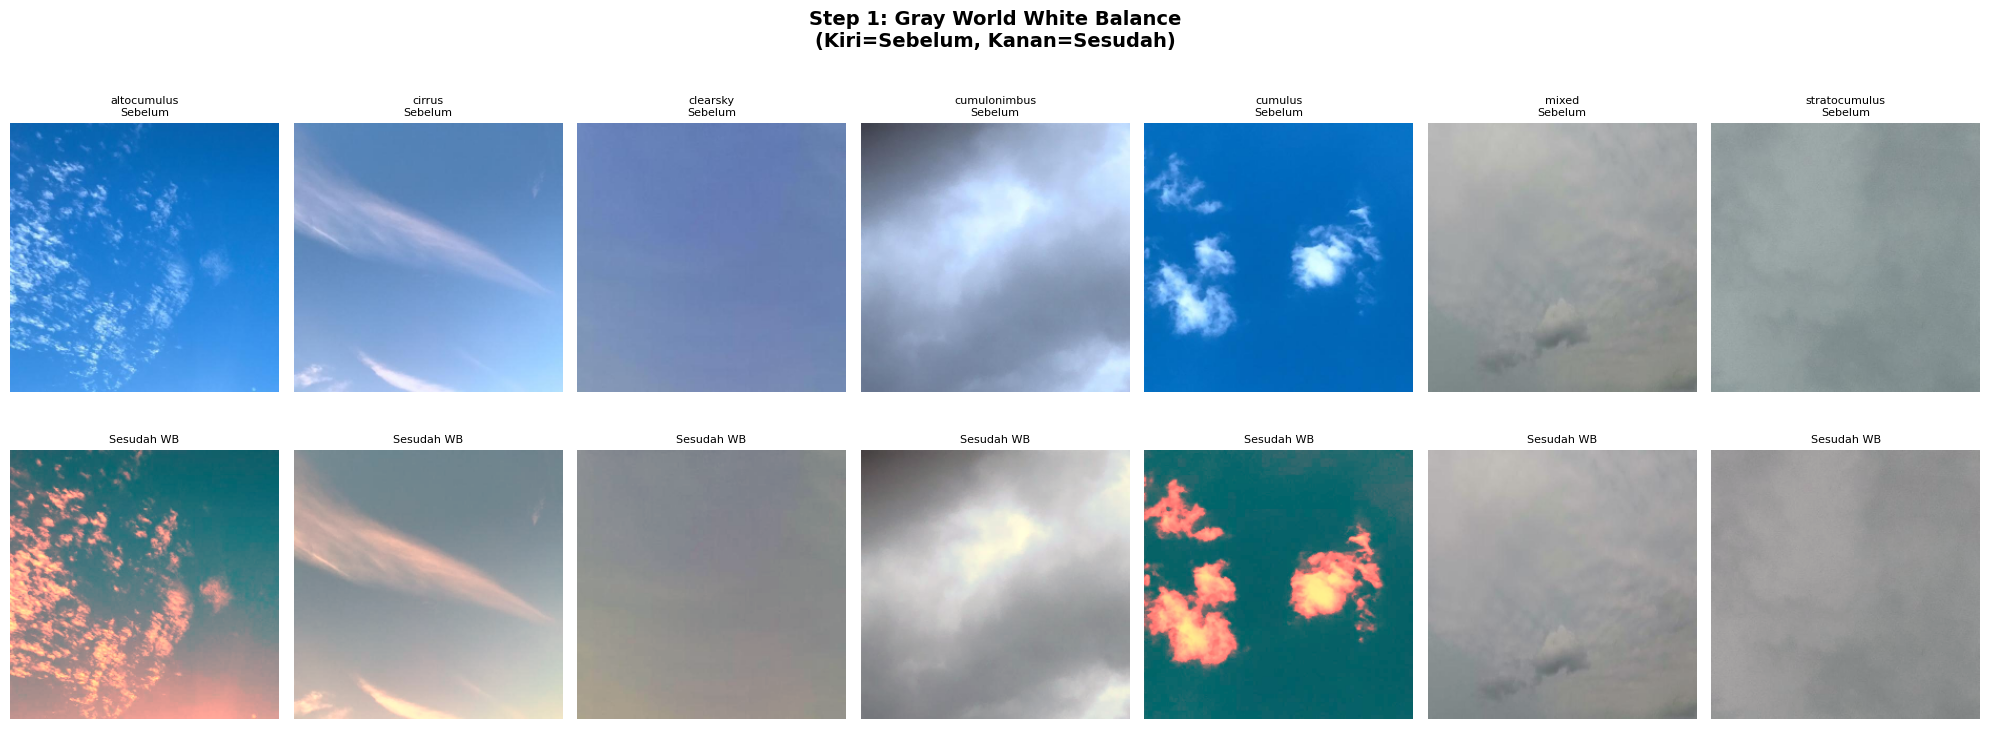

    Channel B: mean 215.0 → 131.1
    Channel G: mean 133.7 → 131.1
    Channel R: mean 46.2 → 125.2


In [7]:
# Visualisasi Preprocessing Bertahap secara otomatis untuk semua tahapan
visualize_pipeline_steps(images, labels, PIPELINE)


In [11]:
# ============================================================
# GLCM Functions (identik dengan baseline)
# ============================================================
def glcm(image, angle):
    angles_map = {0: 0, 45: np.pi/4, 90: np.pi/2, 135: 3*np.pi/4}
    angle_rad = angles_map[angle]
    matriks = graycomatrix(image, distances=[1], angles=[angle_rad],
                           levels=256, symmetric=True, normed=True)
    return matriks

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

print("Helper functions defined:")
print("  - GLCM functions: glcm, contrast, dissimilarity, homogenity, ASM, energy, entropyGlcm, correlation")
print("  - Color function: extract_color_features (imported from src.image_processing)")
print("  - Total fitur per gambar: 7 properti × 4 sudut + 9 warna = 37 fitur")


Helper functions defined:
  - GLCM functions: glcm, contrast, dissimilarity, homogenity, ASM, energy, entropyGlcm, correlation
  - Color function: extract_color_features (imported from src.image_processing)
  - Total fitur per gambar: 7 properti × 4 sudut + 9 warna = 37 fitur


## Feature Extraction (GLCM Tekstur + RGB Warna)

In [12]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

color_mean_r, color_mean_g, color_mean_b = [], [], []
color_std_r, color_std_g, color_std_b = [], [], []
color_skew_r, color_skew_g, color_skew_b = [], [], []

for i in tqdm(range(len(images)), desc="Extracting GLCM + Color features"):
    img = images[i]
    
    img_wb = PIPELINE[0](img)
    img_bf = PIPELINE[1](img_wb)
    img_gray = PIPELINE[2](img_bf)
    img_glcm = PIPELINE[3](img_gray)
    
    g0   = glcm(img_glcm, 0)
    g45  = glcm(img_glcm, 45)
    g90  = glcm(img_glcm, 90)
    g135 = glcm(img_glcm, 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))
    
    color_feat = extract_color_features(img_bf)
    color_mean_r.append(color_feat['Color_Mean_R'])
    color_mean_g.append(color_feat['Color_Mean_G'])
    color_mean_b.append(color_feat['Color_Mean_B'])
    color_std_r.append(color_feat['Color_Std_R'])
    color_std_g.append(color_feat['Color_Std_G'])
    color_std_b.append(color_feat['Color_Std_B'])
    color_skew_r.append(color_feat['Color_Skew_R'])
    color_skew_g.append(color_feat['Color_Skew_G'])
    color_skew_b.append(color_feat['Color_Skew_B'])

print("Ekstraksi fitur selesai!")

import gc
del images, images_wb, images_bf, images_gray, images_clahe
gc.collect()
print("Memori citra berhasil dibersihkan! RAM sekarang lega untuk model training.")


Extracting GLCM + Color features: 100%|██████████| 8455/8455 [03:10<00:00, 44.46it/s]

Ekstraksi fitur selesai!
Memori citra berhasil dibersihkan! RAM sekarang lega untuk model training.


In [13]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # GLCM Tekstur
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Fitur Warna RGB
    'Color_Mean_R': color_mean_r, 'Color_Mean_G': color_mean_g, 'Color_Mean_B': color_mean_b,
    'Color_Std_R': color_std_r, 'Color_Std_G': color_std_g, 'Color_Std_B': color_std_b,
    'Color_Skew_R': color_skew_r, 'Color_Skew_G': color_skew_g, 'Color_Skew_B': color_skew_b,
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur tersimpan ke {csv_path}')
print(f'Shape: {df.shape} (gambar × fitur)') 
print(f'Jumlah fitur GLCM: 28, Fitur Warna: 9, Total: {df.shape[1]-2}')
df.head()

Fitur tersimpan ke hasil_ekstraksi_experiment8.csv
Shape: (8455, 39) (gambar × fitur)
Jumlah fitur GLCM: 28, Fitur Warna: 9, Total: 37


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Correlation135,Color_Mean_R,Color_Mean_G,Color_Mean_B,Color_Std_R,Color_Std_G,Color_Std_B,Color_Skew_R,Color_Skew_G,Color_Skew_B
0,2_altocumulus_001371.jpg,altocumulus,87.426808,139.758724,119.529642,210.650596,0.441416,0.322535,0.351448,0.299365,...,0.936187,124.810013,131.014160,131.069931,77.040392,21.586250,12.706473,0.093638,0.359870,-0.378776
1,2_altocumulus_000676.jpg,altocumulus,34.806771,76.725905,53.256495,89.015317,0.266818,0.173032,0.216732,0.164239,...,0.964980,127.631836,127.563248,127.622681,31.332287,23.891321,20.623981,-0.583723,-0.607165,-0.562423
2,2_altocumulus_001452.jpg,altocumulus,53.839323,114.772749,71.718153,124.803860,0.233975,0.150177,0.207117,0.164573,...,0.982069,158.573380,161.083969,161.085266,65.481587,37.292532,19.812127,-0.345916,0.073408,-0.465520
3,2_altocumulus_000336.jpg,altocumulus,118.546844,224.212011,170.901945,275.910158,0.426220,0.322460,0.346662,0.279701,...,0.962773,149.413681,155.636810,155.295410,77.577579,49.800790,29.310221,0.366027,0.472960,0.303605
4,2_altocumulus_000201.jpg,altocumulus,41.163496,113.916832,112.621553,176.253579,0.335892,0.231825,0.273131,0.224578,...,0.948319,148.037704,148.567291,148.522903,41.928781,15.385497,8.533476,0.741632,1.091677,0.802509


## Feature Selection

Total fitur sebelum seleksi: 37

Fitur GLCM (28):
['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Dissimilarity135', 'Entropy0', 'Entropy45', 'Entropy90', 'Entropy135', 'ASM0', 'ASM45', 'ASM90', 'ASM135', 'Energy0', 'Energy45', 'Energy90', 'Energy135', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']

Fitur Warna (9):
['Color_Mean_R', 'Color_Mean_G', 'Color_Mean_B', 'Color_Std_R', 'Color_Std_G', 'Color_Std_B', 'Color_Skew_R', 'Color_Skew_G', 'Color_Skew_B']


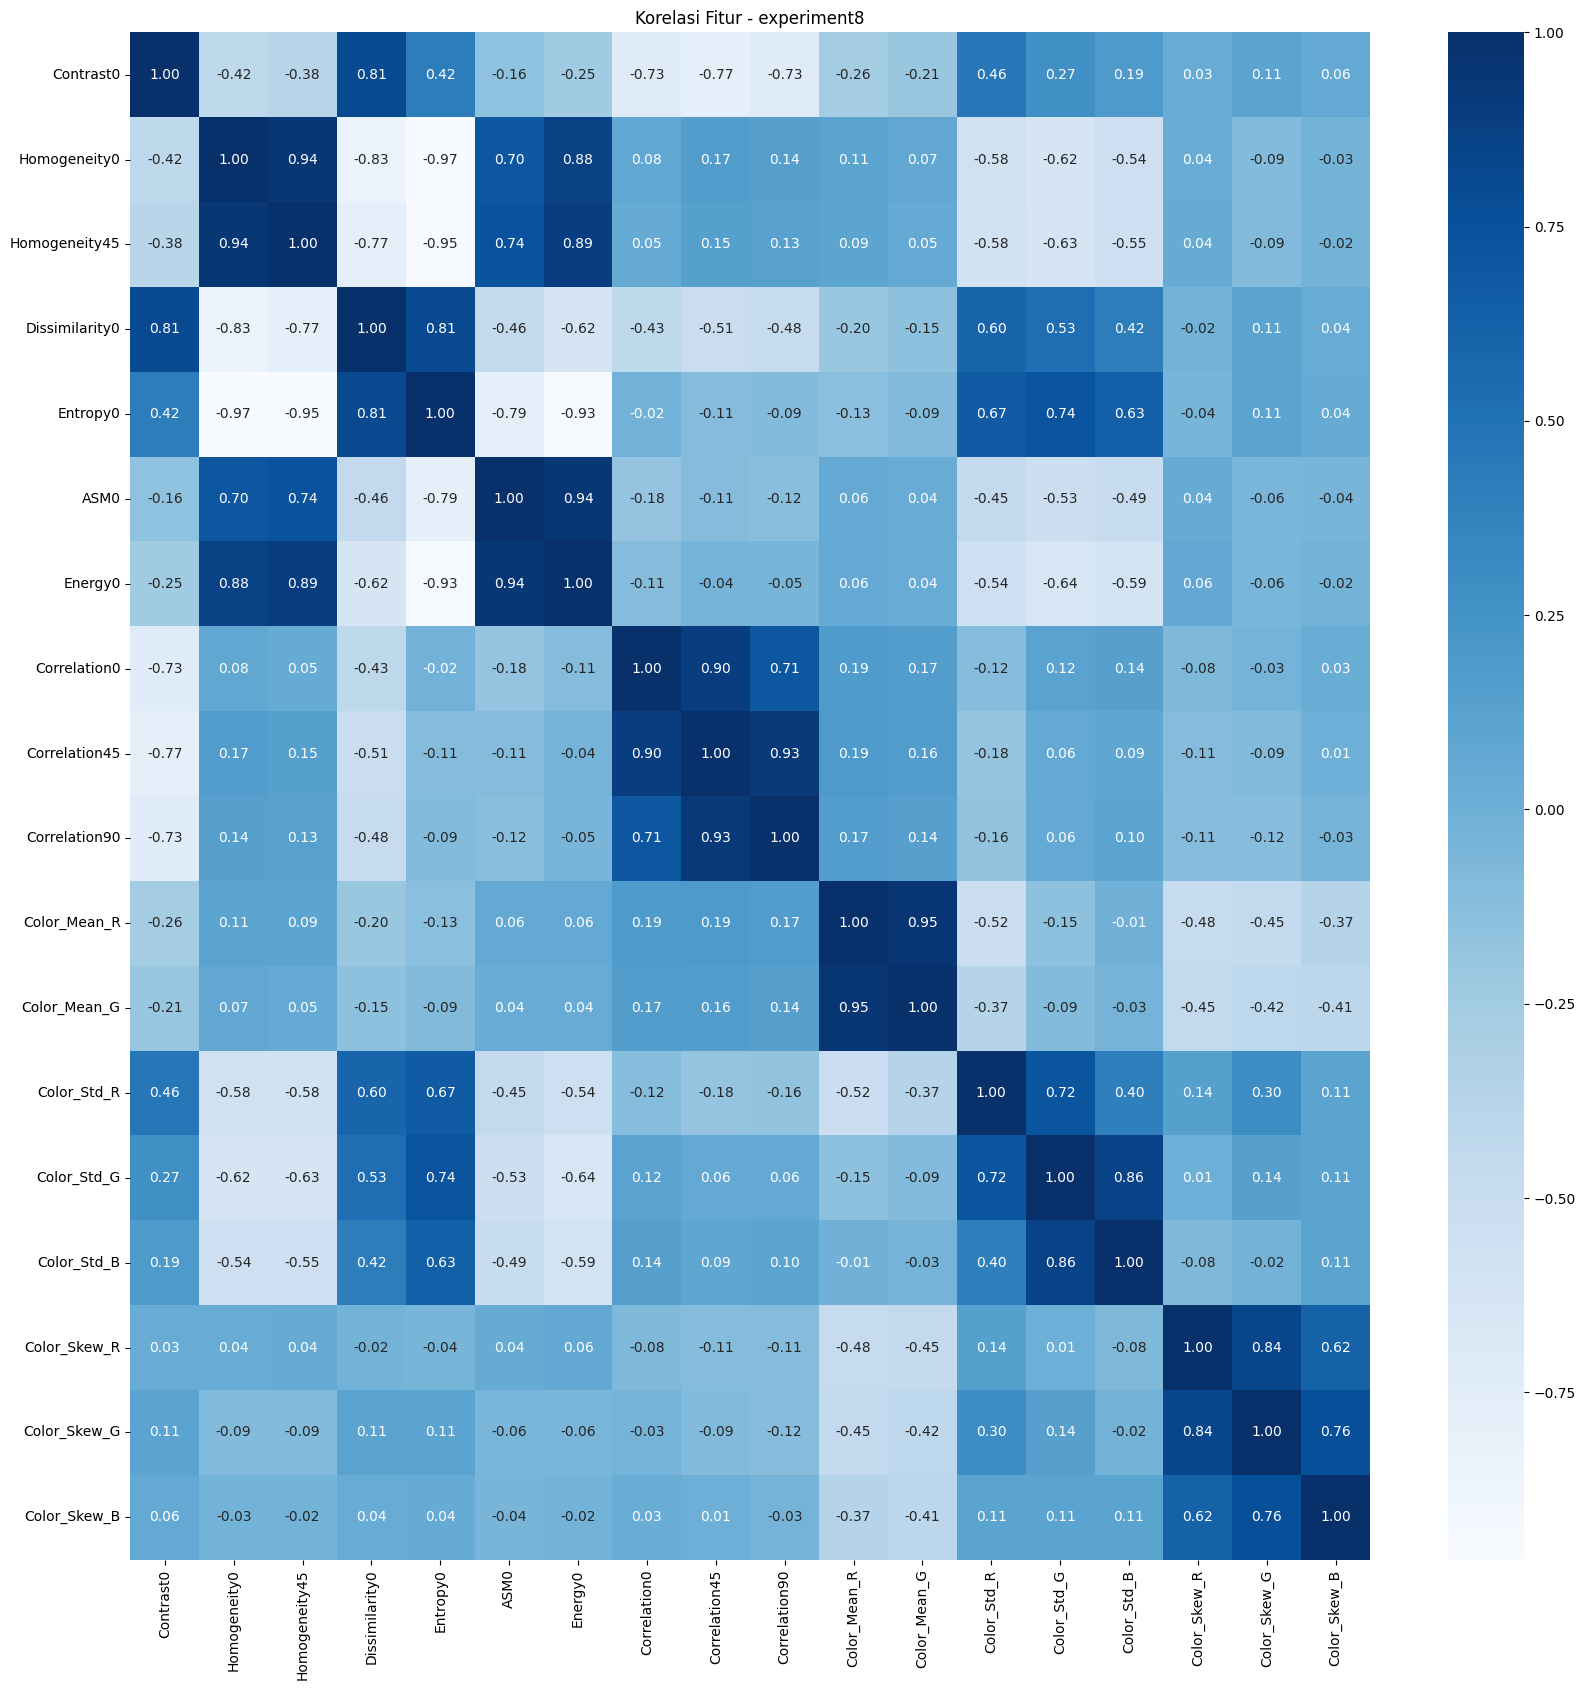

Selected 18 features out of 37


,Contrast0,Homogeneity0,Homogeneity45,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,Color_Mean_R,Color_Mean_G,Color_Std_R,Color_Std_G,Color_Std_B,Color_Skew_R,Color_Skew_G,Color_Skew_B
0,87.426808,0.441416,0.322535,4.270558,7.630034,0.001499,0.038722,0.973605,0.957663,0.963839,124.810013,131.014160,77.040392,21.586250,12.706473,0.093638,0.359870,-0.378776
1,34.806771,0.266818,0.173032,4.037653,7.905085,0.000533,0.023096,0.986387,0.969814,0.979057,127.631836,127.563248,31.332287,23.891321,20.623981,-0.583723,-0.607165,-0.562423
2,53.839323,0.233975,0.150177,4.827466,8.500842,0.000280,0.016732,0.992261,0.983510,0.989700,158.573380,161.083969,65.481587,37.292532,19.812127,-0.345916,0.073408,-0.465520
3,118.546844,0.426220,0.322460,4.627237,7.808244,0.001178,0.034317,0.983983,0.969749,0.976925,149.413681,155.636810,77.577579,49.800790,29.310221,0.366027,0.472960,0.303605
4,41.163496,0.335892,0.231825,3.936382,7.886455,0.000916,0.030273,0.987923,0.966597,0.966982,148.037704,148.567291,41.928781,15.385497,8.533476,0.741632,1.091677,0.802509


In [ ]:
# Kolom fitur (semua selain Filename dan Label)
feature_cols = [c for c in df.columns if c not in ['Filename', 'Label']]
print(f"Total fitur sebelum seleksi: {len(feature_cols)}")
print("\nFitur GLCM (28):")
print([c for c in feature_cols if 'Color' not in c])
print("\nFitur Warna (9):")
print([c for c in feature_cols if 'Color' in c])

# Heatmap korelasi -> drop fitur redundan (threshold 0.95)
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
X = x_new.values
y = df['Label'].values

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new.head()


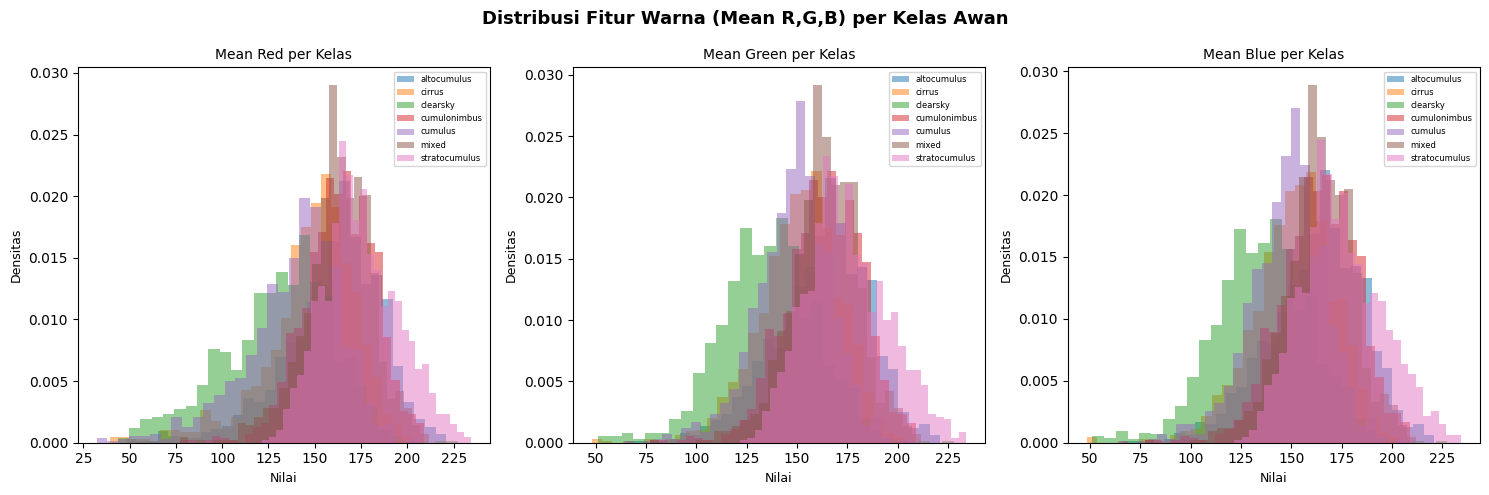

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Fitur Warna (Mean R,G,B) per Kelas Awan', fontsize=13, fontweight='bold')

for ax, (feat, title) in zip(axes, [
    ('Color_Mean_R', 'Mean Red per Kelas'),
    ('Color_Mean_G', 'Mean Green per Kelas'),
    ('Color_Mean_B', 'Mean Blue per Kelas'),
]):
    for cls in class_names:
        vals = df[df['Label']==cls][feat].values
        ax.hist(vals, bins=30, alpha=0.5, label=cls, density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Densitas', fontsize=9)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(f'viz_{EXPERIMENT_NAME}_color_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Train / Test Split dan Normalisasi

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} sampel")
print(f"Testing set:  {X_test.shape[0]} sampel")

Training set: 6764 sampel
Testing set:  1691 sampel


In [17]:
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1 

X_train_norm = (X_train - X_min) / X_range
X_test_norm  = (X_test  - X_min) / X_range

print("Normalisasi Min-Max selesai.")
print(f"X_train_norm shape: {X_train_norm.shape}")
print(f"X_test_norm shape:  {X_test_norm.shape}")

Normalisasi Min-Max selesai.
X_train_norm shape: (6764, 37)
X_test_norm shape:  (1691, 37)


## Model Training & Evaluation

In [18]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")

rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [19]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------
               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1000
       cirrus       1.00      1.00      1.00      1000
     clearsky       1.00      1.00      1.00      1000
 cumulonimbus       1.00      1.00      1.00      1000
      cumulus       1.00      1.00      1.00      1000
        mixed       1.00      1.00      1.00       764
stratocumulus       1.00      1.00      1.00      1000

     accuracy                           1.00      6764
    macro avg       1.00      1.00      1.00      6764
 weighted avg       1.00      1.00      1.00      6764

Accuracy: 1.0

------Random Forest - Testing Set------
               precision    recall  f1-score   support

  altocumulus       0.79      0.74      0.77       250
       cirrus       0.62      0.59      0.60       250
     clearsky       0.84      0.93      0.88       250
 cumulonimbus       0.54      0.61      0.57       250
      cumulus       

## Evaluation - Confusion Matrix

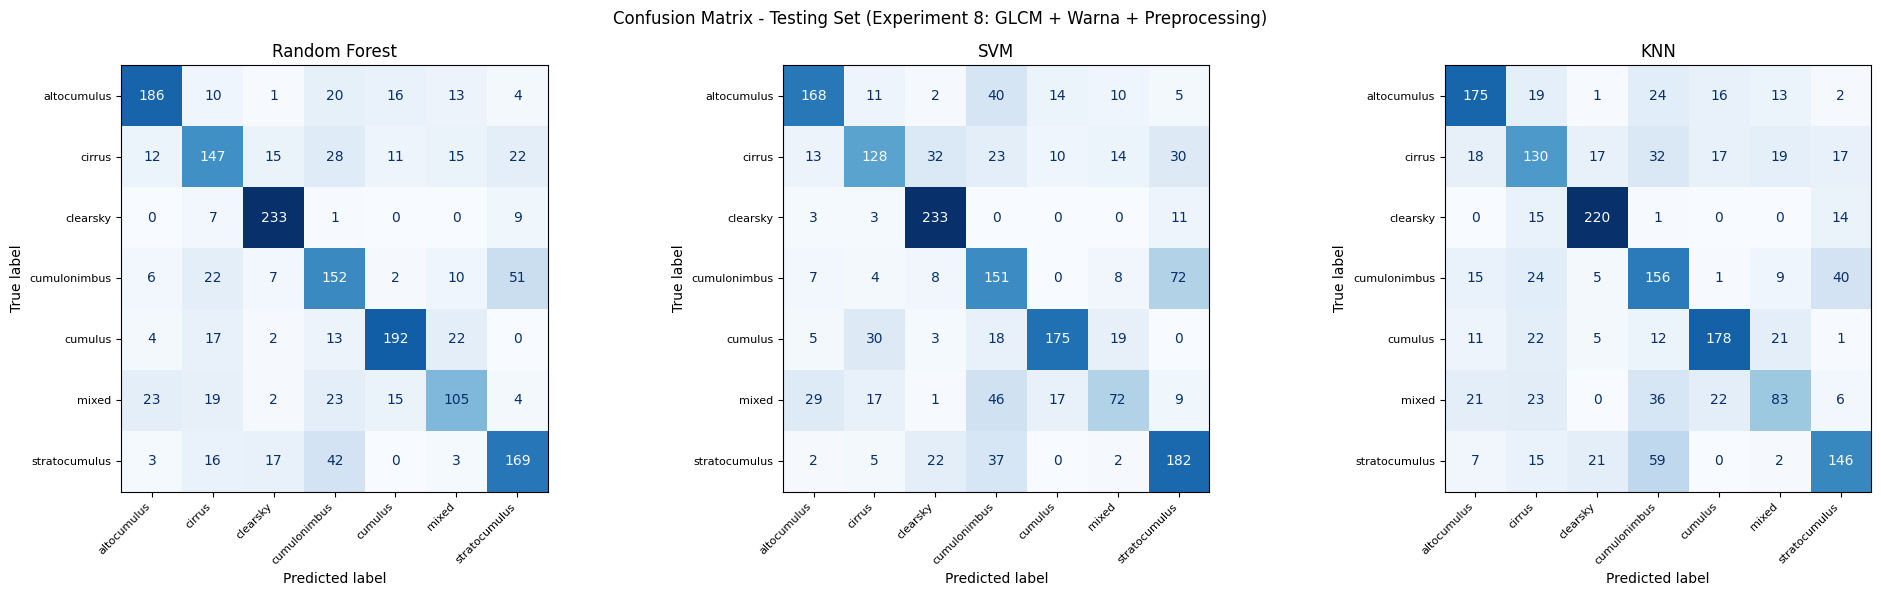

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix - Testing Set (Experiment 8: GLCM + Warna + Preprocessing)', fontsize=12)

for ax, (y_pred, title) in zip(axes, [
    (y_pred_rf_test, 'Random Forest'),
    (y_pred_svm_test, 'SVM'),
    (y_pred_knn_test, 'KNN'),
]):
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(f'viz_{EXPERIMENT_NAME}_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## Analisis Pentingnya Fitur (Random Forest Feature Importance)

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_12752\2584343402.py:19: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_12752\2584343402.py:19: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_12752\2584343402.py:20: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'viz_{EXPERIMENT_NAME}_feature_importance.png', dpi=100, bbox_inches='tight')
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_12752\2584343402.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'viz_{EXPERIMENT_NAME}_feature_importance.png', dpi=100, bbox_inches='tight')
c:\Users\Mahesa\miniconda3\envs\imgproc\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) D

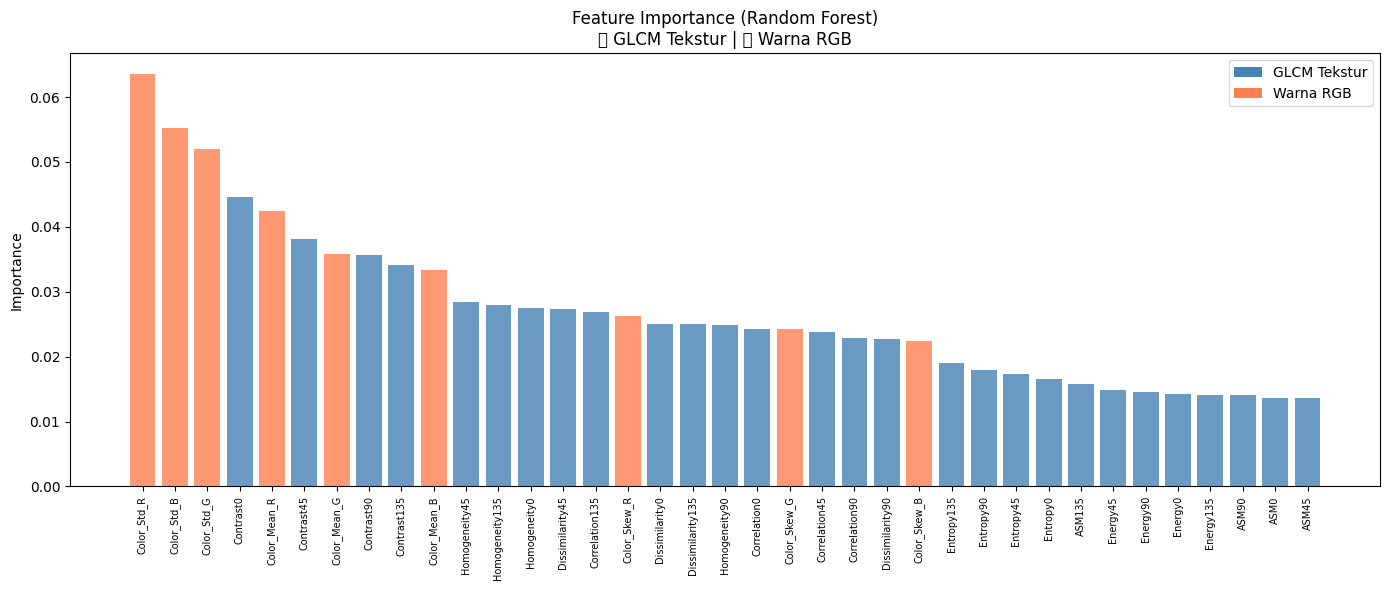


Total Importance - GLCM Tekstur: 0.6446 (64.5%)
Total Importance - Fitur Warna:   0.3554 (35.5%)


In [21]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['coral' if 'Color' in feature_cols[i] else 'steelblue' for i in indices]
ax.bar(range(len(feature_cols)), importances[indices], color=colors, alpha=0.8)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in indices], rotation=90, fontsize=7)
ax.set_title('Feature Importance (Random Forest)\n🔵 GLCM Tekstur | 🔴 Warna RGB', fontsize=12)
ax.set_ylabel('Importance', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='GLCM Tekstur'),
    Patch(facecolor='coral', label='Warna RGB')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(f'viz_{EXPERIMENT_NAME}_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

glcm_importance = sum(importances[i] for i, feat in enumerate(feature_cols) if 'Color' not in feat)
color_importance = sum(importances[i] for i, feat in enumerate(feature_cols) if 'Color' in feat)
print(f"\nTotal Importance - GLCM Tekstur: {glcm_importance:.4f} ({glcm_importance*100:.1f}%)")
print(f"Total Importance - Fitur Warna:   {color_importance:.4f} ({color_importance*100:.1f}%)")

## Perbandingan dengan Baseline

Berikut adalah perbandingan ringkasan hasil experiment ini vs baseline:

In [22]:
results = {
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, y_pred_rf_train),
        accuracy_score(y_train, y_pred_svm_train),
        accuracy_score(y_train, y_pred_knn_train),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, y_pred_rf_test),
        accuracy_score(y_test, y_pred_svm_test),
        accuracy_score(y_test, y_pred_knn_test),
    ],
    'F1_Test_Macro': [
        f1_score(y_test, y_pred_rf_test, average='macro'),
        f1_score(y_test, y_pred_svm_test, average='macro'),
        f1_score(y_test, y_pred_knn_test, average='macro'),
    ]
}
results_df = pd.DataFrame(results)
print("=" * 70)
print(f"EXPERIMENT 8: GLCM + Warna RGB | Pipeline: WB → BF → CLAHE")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

EXPERIMENT 8: GLCM + Warna RGB | Pipeline: WB → BF → CLAHE
        Model  Accuracy_Train  Accuracy_Test  F1_Test_Macro
Random Forest        1.000000       0.700177       0.695586
          SVM        0.659521       0.655825       0.644859
          KNN        0.766410       0.643406       0.637368


In [23]:
from pathlib import Path
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil diperbarui dengan tabel hasil terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (27 baris total)
README.md berhasil diperbarui dengan tabel hasil terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment3,rf,0.655789,0.654693,0.655789,0.653106
1,experiment3,svm,0.609211,0.621162,0.609211,0.603450
2,experiment3,knn,0.621053,0.615394,0.621053,0.613233
3,experiment4,rf,0.832105,0.831199,0.832105,0.831413
4,experiment4,svm,0.791842,0.800839,0.791842,0.794697
5,experiment4,knn,0.776579,0.769591,0.776579,0.770272
6,baseline,rf,0.513897,0.514438,0.513897,0.513258
7,baseline,svm,0.498522,0.528703,0.498522,0.504854
8,baseline,knn,0.479598,0.479948,0.479598,0.477134
9,experiment5,rf,0.819042,0.818971,0.819042,0.818742
